# Convolutional Neural Networks

## Project: Write an Algorithm for a Dog Identification App 

---

In this notebook, some template code has already been provided for you, and you will need to implement additional functionality to successfully complete this project. You will not need to modify the included code beyond what is requested. Sections that begin with **'(IMPLEMENTATION)'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section, and the specifics of the implementation are marked in the code block with a 'TODO' statement. Please be sure to read the instructions carefully! 

> **Note**: Once you have completed all of the code implementations, you need to finalize your work by exporting the Jupyter Notebook as an HTML document. Before exporting the notebook to html, all of the code cells need to have been run so that reviewers can see the final implementation and output. You can then export the notebook by using the menu above and navigating to **File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut.  Markdown cells can be edited by double-clicking the cell to enter edit mode.

The rubric contains _optional_ "Stand Out Suggestions" for enhancing the project beyond the minimum requirements. If you decide to pursue the "Stand Out Suggestions", you should include the code in this Jupyter notebook.



---
### Why We're Here 

In this notebook, you will make the first steps towards developing an algorithm that could be used as part of a mobile or web app.  At the end of this project, your code will accept any user-supplied image as input.  If a dog is detected in the image, it will provide an estimate of the dog's breed.  If a human is detected, it will provide an estimate of the dog breed that is most resembling.  The image below displays potential sample output of your finished project (... but we expect that each student's algorithm will behave differently!). 

![Sample Dog Output](images/sample_dog_output.png)

In this real-world setting, you will need to piece together a series of models to perform different tasks; for instance, the algorithm that detects humans in an image will be different from the CNN that infers dog breed.  There are many points of possible failure, and no perfect algorithm exists.  Your imperfect solution will nonetheless create a fun user experience!

### The Road Ahead

We break the notebook into separate steps.  Feel free to use the links below to navigate the notebook.

* [Step 0](#step0): Import Datasets
* [Step 1](#step1): Detect Humans
* [Step 2](#step2): Detect Dogs
* [Step 3](#step3): Create a CNN to Classify Dog Breeds (from Scratch)
* [Step 4](#step4): Create a CNN to Classify Dog Breeds (using Transfer Learning)
* [Step 5](#step5): Write your Algorithm
* [Step 6](#step6): Test Your Algorithm

---
<a id='step0'></a>
## Step 0: Import Datasets

Make sure that you've downloaded the required human and dog datasets:
* Download the [dog dataset](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip).  Unzip the folder and place it in this project's home directory, at the location `/dog_images`. 

* Download the [human dataset](https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/lfw.zip).  Unzip the folder and place it in the home directory, at location `/lfw`.  

*Note: If you are using a Windows machine, you are encouraged to use [7zip](http://www.7-zip.org/) to extract the folder.*

In the code cell below, we save the file paths for both the human (LFW) dataset and dog dataset in the numpy arrays `human_files` and `dog_files`.

In [4]:
import numpy as np
from glob import glob

# load filenames for human and dog images
human_files = np.array(glob("./lfw/*/*"))
dog_files = np.array(glob("./dog_images/*/*/*"))

# print number of images in each dataset
print('There are %d total human images.' % len(human_files))
print('There are %d total dog images.' % len(dog_files))

There are 13233 total human images.
There are 8351 total dog images.


In [5]:
human_files[0]

np.str_('./lfw/Lane_Odom/Lane_Odom_0001.jpg')

In [6]:
human_files[1]

np.str_('./lfw/Joseph_Blatter/Joseph_Blatter_0001.jpg')

In [7]:
dog_files[0]

np.str_('./dog_images/test/128.Smooth_fox_terrier/Smooth_fox_terrier_08116.jpg')

In [8]:
dog_files[1]

np.str_('./dog_images/test/128.Smooth_fox_terrier/Smooth_fox_terrier_08113.jpg')

<a id='step1'></a>
## Step 1: Detect Humans

In this section, we use OpenCV's implementation of [Haar feature-based cascade classifiers](http://docs.opencv.org/trunk/d7/d8b/tutorial_py_face_detection.html) to detect human faces in images.  

OpenCV provides many pre-trained face detectors, stored as XML files on [github](https://github.com/opencv/opencv/tree/master/data/haarcascades).  We have downloaded one of these detectors and stored it in the `haarcascades` directory.  In the next code cell, we demonstrate how to use this detector to find human faces in a sample image.

Number of faces detected: 1


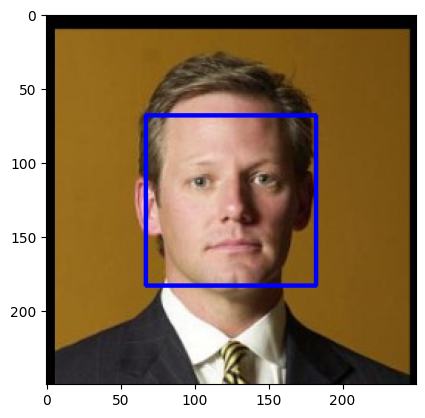

In [10]:
import cv2                
import matplotlib.pyplot as plt                        
%matplotlib inline                               

# extract pre-trained face detector
face_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_frontalface_alt.xml')

# load color (BGR) image
img = cv2.imread(human_files[0])
# convert BGR image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# find faces in image
faces = face_cascade.detectMultiScale(gray)

# print number of faces detected in the image
print('Number of faces detected:', len(faces))

# get bounding box for each detected face
for (x,y,w,h) in faces:
    # add bounding box to color image
    cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    
# convert BGR image to RGB for plotting
cv_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# display the image, along with bounding box
plt.imshow(cv_rgb)
plt.show()

Before using any of the face detectors, it is standard procedure to convert the images to grayscale.  The `detectMultiScale` function executes the classifier stored in `face_cascade` and takes the grayscale image as a parameter.  

In the above code, `faces` is a numpy array of detected faces, where each row corresponds to a detected face.  Each detected face is a 1D array with four entries that specifies the bounding box of the detected face.  The first two entries in the array (extracted in the above code as `x` and `y`) specify the horizontal and vertical positions of the top left corner of the bounding box.  The last two entries in the array (extracted here as `w` and `h`) specify the width and height of the box.

### Write a Human Face Detector

We can use this procedure to write a function that returns `True` if a human face is detected in an image and `False` otherwise.  This function, aptly named `face_detector`, takes a string-valued file path to an image as input and appears in the code block below.

In [11]:
# returns "True" if face is detected in image stored at img_path
def face_detector(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray)
    return len(faces) > 0

### (IMPLEMENTATION) Assess the Human Face Detector

__Question 1:__ Use the code cell below to test the performance of the `face_detector` function.  
- What percentage of the first 100 images in `human_files` have a detected human face?  
- What percentage of the first 100 images in `dog_files` have a detected human face? 

Ideally, we would like 100% of human images with a detected face and 0% of dog images with a detected face.  You will see that our algorithm falls short of this goal, but still gives acceptable performance.  We extract the file paths for the first 100 images from each of the datasets and store them in the numpy arrays `human_files_short` and `dog_files_short`.

__Answer:__ 
(You can print out your results and/or write your percentages in this cell)
 - Human face percentage of human files:  98.00%
 - Human face percentage of dog files:     7.00%

In [14]:
from tqdm import tqdm

human_files_short = human_files[:100]
dog_files_short = dog_files[:100]

#-#-# Do NOT modify the code above this line. #-#-#

## TODO: Test the performance of the face_detector algorithm 
## on the images in human_files_short and dog_files_short.
# Detect human faces from a collection of human files
total_face_detected = 0
for human_file in human_files_short:
    if face_detector(img_path=human_file) == True:
        total_face_detected += 1

print("Human face percentage of human files: %6.2f%%" % \
      ((total_face_detected / len(human_files_short)) * 100))

# Detect human faces from a collection of dog files
total_face_detected = 0
for dog_file in dog_files_short:
    if face_detector(img_path=dog_file) == True:
        total_face_detected += 1

print("Human face percentage of dog files:   %6.2f%%" % \
      ((total_face_detected / len(dog_files_short)) * 100))

Human face percentage of human files:  98.00%
Human face percentage of dog files:    11.00%


We suggest the face detector from OpenCV as a potential way to detect human images in your algorithm, but you are free to explore other approaches, especially approaches that make use of deep learning :).  Please use the code cell below to design and test your own face detection algorithm.  If you decide to pursue this _optional_ task, report performance on `human_files_short` and `dog_files_short`.

In [9]:
### (Optional) 
### TODO: Test performance of anotherface detection algorithm.
### Feel free to use as many code cells as needed.

---
<a id='step2'></a>
## Step 2: Detect Dogs

In this section, we use a [pre-trained model](http://pytorch.org/docs/master/torchvision/models.html) to detect dogs in images.  

### Obtain Pre-trained VGG-16 Model

The code cell below downloads the VGG-16 model, along with weights that have been trained on [ImageNet](http://www.image-net.org/), a very large, very popular dataset used for image classification and other vision tasks.  ImageNet contains over 10 million URLs, each linking to an image containing an object from one of [1000 categories](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).  

In [17]:
import torch
import torchvision.models as models

# number of subprocesses to use for data loading
num_threads = 24
# Device types: cpu, xpu, cuda
device_type = "xpu"

# define VGG16 model
VGG16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Use GPU when available
device = torch.device(device_type)
print(device)

# move model to GPU if available
VGG16 = VGG16.to(device)

xpu


Get class index to label converter for ImageNet model.

In [18]:
import pickle
from urllib.request import urlopen

clsidx_to_labels = pickle.load(urlopen('https://gist.githubusercontent.com/yrevar/6135f1bd8dcf2e0cc683/raw/d133d61a09d7e5a3b36b8c111a8dd5c4b5d560ee/imagenet1000_clsid_to_human.pkl'))

Given an image, this pre-trained VGG-16 model returns a prediction (derived from the 1000 possible categories in ImageNet) for the object that is contained in the image.

### (IMPLEMENTATION) Making Predictions with a Pre-trained Model

In the next code cell, you will write a function that accepts a path to an image (such as `'dogImages/train/001.Affenpinscher/Affenpinscher_00001.jpg'`) as input and returns the index corresponding to the ImageNet class that is predicted by the pre-trained VGG-16 model.  The output should always be an integer between 0 and 999, inclusive.

Before writing the function, make sure that you take the time to learn  how to appropriately pre-process tensors for pre-trained models in the [PyTorch documentation](http://pytorch.org/docs/stable/torchvision/models.html).

In [20]:
def display_image_tensor(image_t, ax=None, title=None):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    
    # PyTorch tensors assume the color channel is the first dimension
    # but matplotlib assumes is the third dimension
    image_np = image_t.numpy().transpose((1, 2, 0))
    
    # Undo preprocessing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = std * image_np + mean
    
    # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    image_np = np.clip(image_np, 0, 1)
    
    ax.imshow(image_np)
    
    return ax

In [21]:
def preprocess_image(image_pil):
    ''' Scales, crops, and normalizes a PIL image for a PyTorch model,
        returns an Numpy array
    '''
    
    # TODO: Process a PIL image for use in a PyTorch model
    # scale
    width, height = image_pil.size
    shortest_side = min(width, height)
    new_ratio = shortest_side / 256
    new_width, new_height = (int(width/new_ratio), int(height/new_ratio))
    image_pil = image_pil.resize((new_width, new_height))
    # crop
    width, height = image_pil.size
    new_width, new_height = (224, 224)
    left = (width - new_width) / 2
    top = (height - new_height) / 2
    right = (width + new_width) / 2
    bottom = (height + new_height) / 2
    image_pil = image_pil.crop((left, top, right, bottom))
    # convert to RGB
    if image_pil.mode != "RGB":
        image_pil = image_pil.convert("RGB")
    # normalize
    image_np = np.array(image_pil, dtype=np.float32)
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    image_np = ((image_np / 255) - mean) / std
    # transpoose to channel first (CHW)
    image_np = image_np.transpose((2, 0, 1))
    
    return image_np

In [22]:
from PIL import Image
import torchvision.transforms as transforms

def VGG16_predict(img_path):
    '''
    Use pre-trained VGG-16 model to obtain index corresponding to 
    predicted ImageNet class for image at specified path
    
    Args:
        img_path: path to an image
        
    Returns:
        Index corresponding to VGG-16 model's prediction
    '''
    
    ## TODO: Complete the function.
    ## Load and pre-process an image from the given img_path
    ## Return the *index* of the predicted class for that image
    image_pil = Image.open(img_path)
    image_np = preprocess_image(image_pil)
    image_tensor = torch.tensor(np.array([image_np]))
    image_tensor = image_tensor.to(device)
    output = VGG16(image_tensor)
    prediction = output.topk(1)
    prediction = prediction[1].detach().to("cpu").numpy()

    return prediction[0][0]

In [23]:
def display_and_predict(image_path):
    image_pil = Image.open(image_path)
    image_np = preprocess_image(image_pil)
    display_image_tensor(torch.tensor(image_np))
    plt.show()

    prediction = VGG16_predict(image_path)
    print(prediction, ":", clsidx_to_labels[prediction])

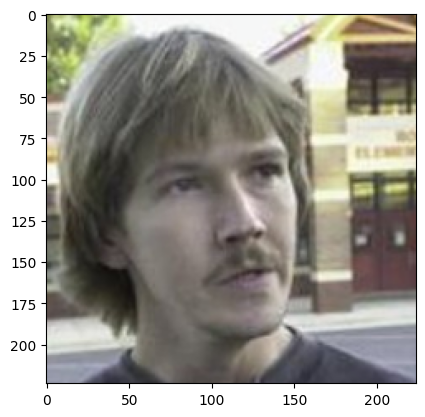

457 : bow tie, bow-tie, bowtie


In [24]:
display_and_predict(image_path='./lfw/Andy_Wisecarver/Andy_Wisecarver_0001.jpg')

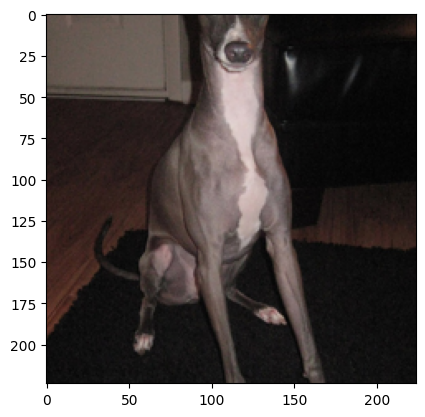

171 : Italian greyhound


In [25]:
display_and_predict(image_path='./dog_images/test/090.Italian_greyhound/Italian_greyhound_06149.jpg')

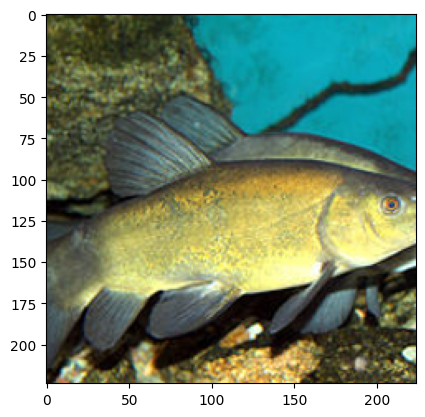

0 : tench, Tinca tinca


In [26]:
display_and_predict(image_path='./test_images/300px-Tinca_tinca_Prague_Vltava_3.jpg')

### (IMPLEMENTATION) Write a Dog Detector

While looking at the [dictionary](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), you will notice that the categories corresponding to dogs appear in an uninterrupted sequence and correspond to dictionary keys 151-268, inclusive, to include all categories from `'Chihuahua'` to `'Mexican hairless'`.  Thus, in order to check to see if an image is predicted to contain a dog by the pre-trained VGG-16 model, we need only check if the pre-trained model predicts an index between 151 and 268 (inclusive).

Use these ideas to complete the `dog_detector` function below, which returns `True` if a dog is detected in an image (and `False` if not).

In [27]:
### returns "True" if a dog is detected in the image stored at img_path
def dog_detector(img_path):
    ## TODO: Complete the function.
    prediction = VGG16_predict(img_path)
    if prediction >= 151 and prediction <= 268:
        is_dog = True
    else:
        is_dog = False
    
    return is_dog # true/false

### (IMPLEMENTATION) Assess the Dog Detector

__Question 2:__ Use the code cell below to test the performance of your `dog_detector` function.  
- What percentage of the images in `human_files_short` have a detected dog?  
- What percentage of the images in `dog_files_short` have a detected dog?

__Answer:__ 
 - Dog percentage of human files:   0.00%
 - Dog percentage of dog files:    98.00%

In [28]:
### TODO: Test the performance of the dog_detector function
### on the images in human_files_short and dog_files_short.

# Detect dog from a collection of human files
total_dog_detected = 0
false_positives = []
for human_file in human_files_short:
    if dog_detector(img_path=human_file) == True:
        total_dog_detected += 1
        false_positives.append(human_file)

print("Dog percentage of human files: %6.2f%%" % \
      ((total_dog_detected / len(human_files_short)) * 100))
print("False Positives:")
for false_positive in false_positives:
    print(" -", false_positive)

# Detect dog from a collection of dog files
total_dog_detected = 0
false_negatives = []
for dog_file in dog_files_short:
    if dog_detector(img_path=dog_file) == True:
        total_dog_detected += 1
    else:
        false_negatives.append(dog_file)

print("")
print("Dog percentage of dog files:   %6.2f%%" % \
      ((total_dog_detected / len(dog_files_short)) * 100))
print("False Negatives:")
for false_negative in false_negatives:
    print(" -", false_negative)

Dog percentage of human files:   0.00%
False Positives:

Dog percentage of dog files:    98.00%
False Negatives:
 - ./dog_images/test/011.Australian_cattle_dog/Australian_cattle_dog_00728.jpg
 - ./dog_images/test/011.Australian_cattle_dog/Australian_cattle_dog_00792.jpg


We suggest VGG-16 as a potential network to detect dog images in your algorithm, but you are free to explore other pre-trained networks (such as [Inception-v3](http://pytorch.org/docs/master/torchvision/models.html#inception-v3), [ResNet-50](http://pytorch.org/docs/master/torchvision/models.html#id3), etc).  Please use the code cell below to test other pre-trained PyTorch models.  If you decide to pursue this _optional_ task, report performance on `human_files_short` and `dog_files_short`.

In [29]:
### (Optional) 
### TODO: Report the performance of another pre-trained network.
### Feel free to use as many code cells as needed.

---
<a id='step3'></a>
## Step 3: Create a CNN to Classify Dog Breeds (from Scratch)

Now that we have functions for detecting humans and dogs in images, we need a way to predict breed from images.  In this step, you will create a CNN that classifies dog breeds.  You must create your CNN _from scratch_ (so, you can't use transfer learning _yet_!), and you must attain a test accuracy of at least 10%.  In Step 4 of this notebook, you will have the opportunity to use transfer learning to create a CNN that attains greatly improved accuracy.

We mention that the task of assigning breed to dogs from images is considered exceptionally challenging.  To see why, consider that *even a human* would have trouble distinguishing between a Brittany and a Welsh Springer Spaniel.  

Brittany | Welsh Springer Spaniel
- | - 
<img src="images/Brittany_02625.jpg" width="100"> | <img src="images/Welsh_springer_spaniel_08203.jpg" width="200">

It is not difficult to find other dog breed pairs with minimal inter-class variation (for instance, Curly-Coated Retrievers and American Water Spaniels).  

Curly-Coated Retriever | American Water Spaniel
- | -
<img src="images/Curly-coated_retriever_03896.jpg" width="200"> | <img src="images/American_water_spaniel_00648.jpg" width="200">


Likewise, recall that labradors come in yellow, chocolate, and black.  Your vision-based algorithm will have to conquer this high intra-class variation to determine how to classify all of these different shades as the same breed.  

Yellow Labrador | Chocolate Labrador | Black Labrador
- | -
<img src="images/Labrador_retriever_06457.jpg" width="150"> | <img src="images/Labrador_retriever_06455.jpg" width="240"> | <img src="images/Labrador_retriever_06449.jpg" width="220">

We also mention that random chance presents an exceptionally low bar: setting aside the fact that the classes are slightly imabalanced, a random guess will provide a correct answer roughly 1 in 133 times, which corresponds to an accuracy of less than 1%.  

Remember that the practice is far ahead of the theory in deep learning.  Experiment with many different architectures, and trust your intuition.  And, of course, have fun!

### (IMPLEMENTATION) Specify Data Loaders for the Dog Dataset

Use the code cell below to write three separate [data loaders](http://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) for the training, validation, and test datasets of dog images (located at `dog_images/train`, `dog_images/valid`, and `dog_images/test`, respectively).  You may find [this documentation on custom datasets](http://pytorch.org/docs/stable/torchvision/datasets.html) to be a useful resource.  If you are interested in augmenting your training and/or validation data, check out the wide variety of [transforms](http://pytorch.org/docs/stable/torchvision/transforms.html?highlight=transform)!

In [30]:
import os
from torchvision import datasets

### TODO: Write data loaders for training, validation, and test sets
## Specify appropriate transforms, and batch_sizes
train_dir = './dog_images/train'
valid_dir = './dog_images/valid'
test_dir = './dog_images/test'

# Data transformations
train_data_transforms = transforms.Compose([transforms.RandomResizedCrop(224), 
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.485, 0.456, 0.406), 
                                                                 (0.229, 0.224, 0.225))])
valid_data_transforms = transforms.Compose([transforms.Resize((224, 224)), 
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.485, 0.456, 0.406), 
                                                                 (0.229, 0.224, 0.225))])

# Datasets
train_datasets = datasets.ImageFolder(train_dir, transform=train_data_transforms)
valid_datasets = datasets.ImageFolder(valid_dir, transform=valid_data_transforms)
test_datasets = datasets.ImageFolder(test_dir, transform=valid_data_transforms)

# Data loader
batch_size = 20
train_loader = torch.utils.data.DataLoader(train_datasets, batch_size=batch_size, 
                                           num_workers=num_threads, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_datasets, batch_size=batch_size, 
                                           num_workers=num_threads, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_datasets, batch_size=batch_size, 
                                          num_workers=num_threads, shuffle=True)

loaders_scratch = {}
loaders_scratch['train'] = train_loader
loaders_scratch['valid'] = valid_loader
loaders_scratch['test'] = test_loader

In [31]:
train_loader.dataset

Dataset ImageFolder
    Number of datapoints: 6680
    Root location: ./dog_images/train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )

In [32]:
valid_loader.dataset

Dataset ImageFolder
    Number of datapoints: 835
    Root location: ./dog_images/valid
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )

In [33]:
test_loader.dataset

Dataset ImageFolder
    Number of datapoints: 836
    Root location: ./dog_images/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )

**Question 3:** Describe your chosen procedure for preprocessing the data. 
- How does your code resize the images (by cropping, stretching, etc)?  What size did you pick for the input tensor, and why?
- Did you decide to augment the dataset?  If so, how (through translations, flips, rotations, etc)?  If not, why not?


**Answer**:
 - For training, I use random cropping to get the model to learn different positions of a same image for every iteration. Many models for image classification use input tensor size of 224x224 with 3-color channel. To avoid engineering debt when switching models, I just follow the commonly used input tensor size.
 - I do not use object translation and scaling as deep learning models have the capability to handle them. As dogs are bound by gravity, I will consider small degree of rotation at the cost of extra computing power.

### (IMPLEMENTATION) Model Architecture

Create a CNN to classify dog breed.  Use the template in the code cell below.

In [34]:
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class Net(nn.Module):
    ### TODO: choose an architecture, and complete the class
    def __init__(self):
        super(Net, self).__init__()
        ## Define layers of a CNN
        self.conv1 = nn.Conv2d(3, 32, kernel_size=(3, 3), \
                               stride=(1, 1), padding=(1, 1), bias=False)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), \
                               stride=(1, 1), padding=(1, 1), bias=False)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), \
                               stride=(1, 1), padding=(1, 1), bias=False)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=(3, 3), \
                               stride=(1, 1), padding=(1, 1), bias=False)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=(3, 3), \
                               stride=(1, 1), padding=(1, 1), bias=False)
        self.pool = nn.MaxPool2d(2, 2)
        self.linear1 = nn.Linear(25088, 4096)
        self.linear2 = nn.Linear(4096, 133)
    
    def forward(self, x):
        ## Define forward behavior
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = F.relu(self.conv5(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.linear1(x))
        x = F.dropout(x)
        x = self.linear2(x)
        return x

#-#-# You so NOT have to modify the code below this line. #-#-#

# instantiate the CNN
model_scratch = Net()

# move tensors to GPU if available
model_scratch.to(device)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=25088, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=133, bias=True)
)

In [35]:
print(model_scratch)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=25088, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=133, bias=True)
)


__Question 4:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  

__Answer:__ 
 - I want to build a model with both CNN and multi-layer perceptron (MLP) for better classification.
 - The input will be 224x224 flatten image with 3 color as the channels with 133 classes as the output.
 - The CNN need to be a bit deeper to avoid flatten layer to be so big that the model will not fit on GPU memory. 3 layers CNN model with 100 thousand nodes of flatten layer does not fit in my GPU memory. 4 layers CNN model has 800 MiB model size and 5 layers CNN model has 400 MiB model size.
 - Need the ReLU for activation function with both linear and non-linear portion that is cheaper to compute as compared to Sigmoid function.
 - Need max pooling and dropout to avoid over fitting and to reduce computational cost as well.

### (IMPLEMENTATION) Specify Loss Function and Optimizer

Use the next code cell to specify a [loss function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [optimizer](http://pytorch.org/docs/stable/optim.html).  Save the chosen loss function as `criterion_scratch`, and the optimizer as `optimizer_scratch` below.

In [36]:
import torch.optim as optim

### TODO: select loss function
criterion_scratch = nn.CrossEntropyLoss()

### TODO: select optimizer
optimizer_scratch = optim.SGD(model_scratch.parameters(), lr=0.001, momentum=0.9)

### (IMPLEMENTATION) Train and Validate the Model

Train and validate your model in the code cell below.  [Save the final model parameters](http://pytorch.org/docs/master/notes/serialization.html) at filepath `'model_scratch.pt'`.

In [39]:
import time

# To avoid following error
# OSError: image file is truncated (150 bytes not processed)
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def train(n_epochs, loaders, model, optimizer, criterion, save_path):
    """returns trained model"""
    # initialize tracker for minimum validation loss
    valid_loss_min = np.inf 
    
    for epoch in range(1, n_epochs+1):
        ###################
        # train the model #
        ###################
        tic = time.time()
        train_loss = 0.0
        total_accumulated_train_loss = 0
        
        model.train()
        for batch_idx, (data, target) in enumerate(loaders['train']):
            # move to GPU
            data, target = data.to(device), target.to(device)
            ## find the loss and update the model parameters accordingly
            ## record the average training loss, using something like
            ## train_loss = train_loss + ((1 / (batch_idx + 1)) * (loss.data - train_loss))
            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # calculate the batch loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # perform a single optimization step (parameter update)
            optimizer.step()
            # update training loss 
            train_loss += loss.item()
            total_accumulated_train_loss += 1
            
            if batch_idx % 100 == 99:    # print training loss every specified number of mini-batches
                print('Epoch %2d, Batch %4d loss: %.16f' %
                      (epoch, batch_idx + 1, train_loss / total_accumulated_train_loss))
                train_loss = 0.0
                total_accumulated_train_loss = 0
            
        train_loss = train_loss / total_accumulated_train_loss
    
        toc = time.time()
        train_time = toc - tic
            
            
        ######################    
        # validate the model #
        ######################
        tic = time.time()
        valid_loss = 0.0
        class_correct = list(0. for i in range(133))
        class_total = list(0. for i in range(133))
        
        model.eval()
        for batch_idx, (data, target) in enumerate(loaders['valid']):
            # move to GPU
            data, target = data.to(device), target.to(device)
            ## update the average validation loss
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # calculate the batch loss
            loss = criterion(output, target)
            # update  validation loss 
            valid_loss += loss.item() * data.size(0)
            # convert output probabilities to predicted class
            _, pred = torch.max(output, 1)    
            # compare predictions to true label
            correct_tensor = pred.eq(target.data.view_as(pred))
            correct = np.squeeze(correct_tensor.to("cpu").numpy())
            # calculate validation accuracy for each object class
            for i in range(len(target)):
                label = target.data[i]
                class_correct[label] += correct[i].item()
                class_total[label] += 1
                
        # calculate avg validation loss
        valid_loss = valid_loss / len(valid_loader.dataset)

        toc = time.time()
        valid_time = toc - tic

        print("Train Time          : %9d seconds" % int(train_time))
        print('Train Loss          : {:9.6f}'.format(train_loss))
        print("Validation Time     : %9d seconds" % int(valid_time))
        print('Validation Loss     : {:9.6f}'.format(valid_loss))
        valid_accuracy = (100. * np.sum(class_correct)) / np.sum(class_total)
        print('Validation Accuracy : %2d%% (%2d/%2d)' % (valid_accuracy, 
                                                         np.sum(class_correct), 
                                                         np.sum(class_total)))
        
        # print training/validation statistics 
        print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
            epoch, 
            train_loss,
            valid_loss
            ))
        
        ## TODO: save the model if validation loss has decreased
        if valid_loss < valid_loss_min:
            print('Saving Checkpoint...')
            torch.save(model.state_dict(), save_path)
            valid_loss_min = valid_loss
            
    # return trained model
    return model

In [40]:
# train the model
model_scratch = train(100, loaders_scratch, model_scratch, 
                      optimizer_scratch, criterion_scratch, 
                      'model_scratch.pt')

# load the model that got the best validation accuracy
model_scratch.load_state_dict(torch.load('model_scratch.pt'))

Epoch  1, Batch  100 loss: 4.8898130750656126
Epoch  1, Batch  200 loss: 4.8892480468750001
Epoch  1, Batch  300 loss: 4.8877333927154538
Train Time          :        16 seconds
Train Loss          :  4.886716
Validation Time     :         1 seconds
Validation Loss     :  4.885442
Validation Accuracy :  0% ( 8/835)
Epoch: 1 	Training Loss: 4.886716 	Validation Loss: 4.885442
Saving Checkpoint...
Epoch  2, Batch  100 loss: 4.8840829992294310
Epoch  2, Batch  200 loss: 4.8826057577133177
Epoch  2, Batch  300 loss: 4.8762953376770017
Train Time          :        15 seconds
Train Loss          :  4.870756
Validation Time     :         1 seconds
Validation Loss     :  4.866903
Validation Accuracy :  1% (13/835)
Epoch: 2 	Training Loss: 4.870756 	Validation Loss: 4.866903
Saving Checkpoint...
Epoch  3, Batch  100 loss: 4.8684154605865482
Epoch  3, Batch  200 loss: 4.8595145750045781
Epoch  3, Batch  300 loss: 4.8614412212371825
Train Time          :        15 seconds
Train Loss          :  4

<All keys matched successfully>

## Compute Utilization

### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

```
...
Epoch 97, Batch  100 loss: 1.0276434421539307
Epoch 97, Batch  200 loss: 0.9928725266456604
Epoch 97, Batch  300 loss: 0.9689174512028694
Train Time          :        33 seconds
Train Loss          :  0.999203
Validation Time     :         2 seconds
Validation Loss     :  5.414416
Validation Accuracy : 16% (139/835)
Epoch: 97 	Training Loss: 0.999203 	Validation Loss: 5.414416
Epoch 98, Batch  100 loss: 0.9258281761407852
Epoch 98, Batch  200 loss: 0.9276315912604332
Epoch 98, Batch  300 loss: 0.9633502592146397
Train Time          :        33 seconds
Train Loss          :  1.043431
Validation Time     :         2 seconds
Validation Loss     :  5.531893
Validation Accuracy : 16% (136/835)
Epoch: 98 	Training Loss: 1.043431 	Validation Loss: 5.531893
Epoch 99, Batch  100 loss: 0.8693333789706230
Epoch 99, Batch  200 loss: 0.8860180363059044
Epoch 99, Batch  300 loss: 0.9737803786993027
Train Time          :        33 seconds
Train Loss          :  0.911569
Validation Time     :         2 seconds
Validation Loss     :  5.303066
Validation Accuracy : 16% (134/835)
Epoch: 99 	Training Loss: 0.911569 	Validation Loss: 5.303066
...
```

Training GPU utilization:
```
while sleep 0.2; do nvidia-smi --query-gpu=name,index,temperature.gpu,utilization.gpu,utilization.memory,memory.total,memory.free,memory.used --format=csv,noheader; done
```
```
GeForce GTX 1060, 0, 72, 98 %, 72 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 96 %, 75 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 96 %, 71 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 98 %, 72 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 96 %, 78 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 98 %, 68 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 97 %, 79 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 96 %, 71 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 98 %, 69 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 72, 96 %, 78 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 73, 97 %, 73 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 73, 97 %, 73 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 73, 96 %, 73 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 73, 96 %, 71 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 73, 96 %, 75 %, 6078 MiB, 2385 MiB, 3693 MiB
GeForce GTX 1060, 0, 73, 98 %, 73 %, 6078 MiB, 2385 MiB, 3693 MiB
```

Validation GPU utilization:
```
while sleep 0.2; do nvidia-smi --query-gpu=name,index,temperature.gpu,utilization.gpu,utilization.memory,memory.total,memory.free,memory.used --format=csv,noheader; done
```
```
GeForce GTX 1060, 0, 76, 4 %, 1 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 76, 47 %, 29 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 77, 64 %, 43 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 76, 26 %, 18 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 77, 71 %, 44 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 77, 83 %, 57 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 77, 86 %, 59 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 76, 33 %, 19 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 75, 17 %, 2 %, 6078 MiB, 1709 MiB, 4369 MiB
GeForce GTX 1060, 0, 75, 4 %, 1 %, 6078 MiB, 1709 MiB, 4369 MiB
```

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

```
...
Epoch 97, Batch  100 loss: 1.2665769594907761
Epoch 97, Batch  200 loss: 1.3437749481201171
Epoch 97, Batch  300 loss: 1.4327021488547325
Train Time          :        15 seconds
Train Loss          :  1.328051
Validation Time     :         1 seconds
Validation Loss     :  4.972976
Validation Accuracy : 15% (130/835)
Epoch: 97 	Training Loss: 1.328051 	Validation Loss: 4.972976
Epoch 98, Batch  100 loss: 1.3893830755352974
Epoch 98, Batch  200 loss: 1.2707574632763863
Epoch 98, Batch  300 loss: 1.3985817331075667
Train Time          :        15 seconds
Train Loss          :  1.377274
Validation Time     :         1 seconds
Validation Loss     :  5.028009
Validation Accuracy : 18% (152/835)
Epoch: 98 	Training Loss: 1.377274 	Validation Loss: 5.028009
Epoch 99, Batch  100 loss: 1.3025741440057754
Epoch 99, Batch  200 loss: 1.2820719981193542
Epoch 99, Batch  300 loss: 1.3465138444304465
Train Time          :        15 seconds
Train Loss          :  1.482776
Validation Time     :         1 seconds
Validation Loss     :  4.842116
Validation Accuracy : 20% (167/835)
Epoch: 99 	Training Loss: 1.482776 	Validation Loss: 4.842116
...
```

Training utilization:

```
$ top

top - 01:44:27 up 1 day,  3:29,  1 user,  load average: 1.08, 0.61, 0.49
Tasks: 611 total,   3 running, 607 sleeping,   0 stopped,   1 zombie
%Cpu(s):  7.2 us,  4.0 sy,  0.0 ni, 85.7 id,  3.0 wa,  0.0 hi,  0.0 si,  0.0 st 
MiB Mem :  31434.1 total,  15399.3 free,   7565.2 used,   9934.9 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  23868.8 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
1105001 eka       20   0   12.7g   1.6g 604848 R  98.7   5.2   1:28.51 python               
   4097 eka       20   0   12.1g 639356 295456 S  15.3   2.0  16:40.39 firefox              
   3203 eka       20   0 5352352 329008 133872 S  13.0   1.0  12:34.56 gnome-shell          
   5492 eka       20   0  726300  72208  43436 S   9.3   0.2   0:21.07 gnome-terminal-      
1107677 eka       20   0   12.6g   1.1g  66816 S   9.0   3.7   0:00.78 pt_data_worker       
1107670 eka       20   0   12.6g   1.1g  66168 S   8.3   3.7   0:00.67 pt_data_worker       
1107665 eka       20   0   12.5g   1.1g  66240 S   7.3   3.5   0:00.72 pt_data_worker       
1107669 eka       20   0   12.5g   1.1g  66624 S   7.3   3.6   0:00.64 pt_data_worker       
1107686 eka       20   0   12.6g   1.1g  66360 S   6.3   3.6   0:00.54 pt_data_worker       
1107671 eka       20   0   12.6g   1.1g  66360 S   6.0   3.7   0:00.66 pt_data_worker       
1107666 eka       20   0   12.6g   1.1g  66624 S   5.7   3.7   0:00.58 pt_data_worker       
1107676 eka       20   0   12.5g   1.1g  66552 S   5.7   3.6   0:00.67 pt_data_worker       
1107681 eka       20   0   12.5g   1.1g  66624 S   5.7   3.6   0:00.56 pt_data_worker       
1107675 eka       20   0   12.6g   1.1g  66624 S   5.3   3.7   0:00.57 pt_data_worker       
1104373 eka       20   0 3036640 520348 112484 S   5.0   1.6   1:04.16 Isolated Web Co      
1107667 eka       20   0   12.5g   1.1g  66240 S   5.0   3.6   0:00.68 pt_data_worker       
1107668 eka       20   0   12.6g   1.1g  66624 S   5.0   3.7   0:00.52 pt_data_worker       
```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 2402/2402 MHz;   0% RC6;     2543 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    0.06% |▏                                               |      0%      0%
         Blitter   80.41% |██████████████████████████████████████▋         |     78%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   94.17% |█████████████████████████████████████████████▎  |      0%      0%

    PID   Render/3D     Blitter       Video    VideoEnhance    Compute    NAME              
1105001 |           ||████████▉  ||           ||           ||██████████▌ python            
```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      41.03      29.01       0.00
 SKT   0     0.00     0.00      40.19      28.25       0.00
 SKT   0     0.00     0.00      39.64      27.72       0.00
 SKT   0     0.00     0.00      38.33      26.72       0.00
 SKT   0     0.00     0.00      39.37      27.60       0.00
 SKT   0     0.00     0.00      38.60      26.96       0.00
 SKT   0     0.00     0.00      38.61      26.89       0.00
 SKT   0     0.00     0.00      40.10      28.12       0.00
 SKT   0     0.00     0.00      41.49      29.29       0.00
 SKT   0     0.00     0.00      40.85      28.95       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+-----------------------------+
| Device ID                   | 1                           |
+-----------------------------+-----------------------------+
| GPU Utilization (%)         | N/A                         |
| EU Array Active (%)         | N/A                         |
| EU Array Stall (%)          | N/A                         |
| EU Array Idle (%)           | N/A                         |
|                             |                             |
| Compute Engine Util (%)     | N/A                         |
| Render Engine Util (%)      | Engine 0: 0                 |
| Media Engine Util (%)       | N/A                         |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Copy Engine Util (%)        | Engine 0: 76                |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0    |
| 3D Engine Util (%)          | N/A                         |
+-----------------------------+-----------------------------+
| Reset                       | N/A                         |
| Programming Errors          | N/A                         |
| Driver Errors               | N/A                         |
| Cache Errors Correctable    | N/A                         |
| Cache Errors Uncorrectable  | N/A                         |
| Mem Errors Correctable      | N/A                         |
| Mem Errors Uncorrectable    | N/A                         |
+-----------------------------+-----------------------------+
| GPU Power (W)               | 175                         |
| GPU Frequency (MHz)         | 2400                        |
| Media Engine Freq (MHz)     | N/A                         |
| GPU Core Temperature (C)    | N/A                         |
| GPU Memory Temperature (C)  | N/A                         |
| GPU Memory Read (kB/s)      | N/A                         |
| GPU Memory Write (kB/s)     | N/A                         |
| GPU Memory Bandwidth (%)    | N/A                         |
| GPU Memory Used (MiB)       | 3944                        |
| GPU Memory Util (%)         | 24                          |
| Xe Link Throughput (kB/s)   | N/A                         |
+-----------------------------+-----------------------------+
```

Validation utilization:

```
$ top

top - 01:45:42 up 1 day,  3:31,  1 user,  load average: 2.27, 1.07, 0.66
Tasks: 617 total,   2 running, 614 sleeping,   0 stopped,   1 zombie
%Cpu(s):  3.9 us,  3.3 sy,  0.0 ni, 89.8 id,  3.0 wa,  0.0 hi,  0.0 si,  0.0 st 
MiB Mem :  31434.1 total,  15612.5 free,   7353.0 used,   9502.1 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  24081.1 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
1105001 eka       20   0   12.7g   1.6g 604252 R  99.3   5.2   2:40.94 python               
1108513 eka       20   0   12.6g   1.1g  66624 S   4.3   3.7   0:00.80 pt_data_worker       
1108518 eka       20   0   12.6g   1.1g  66432 S   4.3   3.7   0:00.93 pt_data_worker       
1108515 eka       20   0   12.6g   1.1g  66624 S   3.7   3.7   0:00.98 pt_data_worker       
1108519 eka       20   0   12.6g   1.1g  66624 S   3.7   3.6   0:00.92 pt_data_worker       
1108509 eka       20   0   12.6g   1.2g  66624 S   3.3   3.8   0:00.88 pt_data_worker       
1108510 eka       20   0   12.6g   1.1g  66624 S   3.3   3.6   0:00.83 pt_data_worker       
1108514 eka       20   0   12.6g   1.1g  66744 S   3.3   3.6   0:00.86 pt_data_worker       
1108516 eka       20   0   12.5g   1.1g  66432 S   3.3   3.6   0:00.75 pt_data_worker       
1108499 eka       20   0   12.5g   1.1g  66624 S   3.0   3.6   0:00.77 pt_data_worker       
1108505 eka       20   0   12.6g   1.2g  66432 S   3.0   3.7   0:00.75 pt_data_worker       
1108517 eka       20   0   12.6g   1.1g  66624 S   3.0   3.7   0:00.94 pt_data_worker       
1108520 eka       20   0   12.5g   1.1g  66144 S   3.0   3.6   0:00.75 pt_data_worker       
1108521 eka       20   0   12.6g   1.1g  66624 S   3.0   3.7   0:00.80 pt_data_worker       
1108502 eka       20   0   12.6g   1.1g  66816 S   2.7   3.7   0:00.91 pt_data_worker       
1108511 eka       20   0   12.6g   1.1g  66624 S   2.7   3.7   0:00.79 pt_data_worker       
1108512 eka       20   0   12.6g   1.1g  66624 S   2.7   3.7   0:00.68 pt_data_worker       
```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 1660/2396 MHz;  20% RC6;     1976 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    0.84% |▌                                               |      0%      0%
         Blitter    2.29% |█▏                                              |      0%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   48.41% |███████████████████████▎                        |      0%      0%

    PID   Render/3D     Blitter       Video    VideoEnhance    Compute    NAME              
1105001 |           ||▍          ||           ||           ||█████▌     | python            
```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      29.56      18.78       0.00
 SKT   0     0.00     0.00      57.53      44.80       0.00
 SKT   0     0.00     0.00      67.85      54.55       0.00
 SKT   0     0.00     0.00      38.83      26.98       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+-----------------------------+
| Device ID                   | 1                           |
+-----------------------------+-----------------------------+
| GPU Utilization (%)         | N/A                         |
| EU Array Active (%)         | N/A                         |
| EU Array Stall (%)          | N/A                         |
| EU Array Idle (%)           | N/A                         |
|                             |                             |
| Compute Engine Util (%)     | N/A                         |
| Render Engine Util (%)      | Engine 0: 2                 |
| Media Engine Util (%)       | N/A                         |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Copy Engine Util (%)        | Engine 0: 0                 |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0    |
| 3D Engine Util (%)          | N/A                         |
+-----------------------------+-----------------------------+
| Reset                       | N/A                         |
| Programming Errors          | N/A                         |
| Driver Errors               | N/A                         |
| Cache Errors Correctable    | N/A                         |
| Cache Errors Uncorrectable  | N/A                         |
| Mem Errors Correctable      | N/A                         |
| Mem Errors Uncorrectable    | N/A                         |
+-----------------------------+-----------------------------+
| GPU Power (W)               | 138                         |
| GPU Frequency (MHz)         | 2400                        |
| Media Engine Freq (MHz)     | N/A                         |
| GPU Core Temperature (C)    | N/A                         |
| GPU Memory Temperature (C)  | N/A                         |
| GPU Memory Read (kB/s)      | N/A                         |
| GPU Memory Write (kB/s)     | N/A                         |
| GPU Memory Bandwidth (%)    | N/A                         |
| GPU Memory Used (MiB)       | 3941                        |
| GPU Memory Util (%)         | 24                          |
| Xe Link Throughput (kB/s)   | N/A                         |
+-----------------------------+-----------------------------+
```

### (IMPLEMENTATION) Test the Model

Try out your model on the test dataset of dog images.  Use the code cell below to calculate and print the test loss and accuracy.  Ensure that your test accuracy is greater than 10%.

In [41]:
def test(loaders, model, criterion):

    # monitor test loss and accuracy
    test_loss = 0.
    correct = 0.
    total = 0.

    model.eval()
    for batch_idx, (data, target) in enumerate(loaders['test']):
        # move to GPU
        data, target = data.to(device), target.to(device)
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss
        loss = criterion(output, target)
        # update average test loss 
        test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss.data - test_loss))
        # convert output probabilities to predicted class
        pred = output.data.max(1, keepdim=True)[1]
        # compare predictions to true label
        correct += np.sum(np.squeeze(pred.eq(target.data.view_as(pred))).cpu().numpy())
        total += data.size(0)
            
    print('Test Loss: {:.6f}\n'.format(test_loss))

    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (
        100. * correct / total, correct, total))

In [42]:
# call test function
test(loaders_scratch, model_scratch, criterion_scratch)

Test Loss: 3.982616


Test Accuracy: 13% (111/836)


---
<a id='step4'></a>
## Step 4: Create a CNN to Classify Dog Breeds (using Transfer Learning)

You will now use transfer learning to create a CNN that can identify dog breed from images.  Your CNN must attain at least 60% accuracy on the test set.

### (IMPLEMENTATION) Specify Data Loaders for the Dog Dataset

Use the code cell below to write three separate [data loaders](http://pytorch.org/docs/master/data.html#torch.utils.data.DataLoader) for the training, validation, and test datasets of dog images (located at `dogImages/train`, `dogImages/valid`, and `dogImages/test`, respectively). 

If you like, **you are welcome to use the same data loaders from the previous step**, when you created a CNN from scratch.

In [48]:
## TODO: Specify data loaders
loaders_transfer = {}
loaders_transfer['train'] = train_loader
loaders_transfer['valid'] = valid_loader
loaders_transfer['test'] = test_loader

### (IMPLEMENTATION) Model Architecture

Use transfer learning to create a CNN to classify dog breed.  Use the code cell below, and save your initialized model as the variable `model_transfer`.

In [49]:
import torchvision.models as models
import torch.nn as nn

## TODO: Specify model architecture 
model_transfer = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
# Freeze training for all "features" layers
for param in model_transfer.features.parameters():
    param.requires_grad = False
    
n_inputs = model_transfer.classifier[6].in_features
n_outputs = 133
# new layers automatically have requires_grad = True
last_layer = nn.Linear(n_inputs, n_outputs)
model_transfer.classifier[6] = last_layer
model_transfer = model_transfer.to(device)

__Question 5:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  Describe why you think the architecture is suitable for the current problem.

__Answer:__ 
 - Since the training data is small and the data is similar (pre-trained VGG16 model has dog's breed classification as well), I will just retrain layers at the end of ConvNet which is the last fully connected layers.
 - I will also change the number of output classes from 1000 to 133.

### (IMPLEMENTATION) Specify Loss Function and Optimizer

Use the next code cell to specify a [loss function](http://pytorch.org/docs/master/nn.html#loss-functions) and [optimizer](http://pytorch.org/docs/master/optim.html).  Save the chosen loss function as `criterion_transfer`, and the optimizer as `optimizer_transfer` below.

In [50]:
criterion_transfer = nn.CrossEntropyLoss()
optimizer_transfer = optim.SGD(model_transfer.classifier.parameters(), lr=0.001, momentum=0.9)

### (IMPLEMENTATION) Train and Validate the Model

Train and validate your model in the code cell below.  [Save the final model parameters](http://pytorch.org/docs/master/notes/serialization.html) at filepath `'model_transfer.pt'`.

In [51]:
# train the model
model_transfer = train(10, loaders_transfer, model_transfer, 
                       optimizer_transfer, criterion_transfer, 
                       'model_transfer.pt')

# load the model that got the best validation accuracy (uncomment the line below)
model_transfer.load_state_dict(torch.load('model_transfer.pt'))

Epoch  1, Batch  100 loss: 3.3594828498363496
Epoch  1, Batch  200 loss: 1.6261689060926436
Epoch  1, Batch  300 loss: 1.3552631229162215
Train Time          :        32 seconds
Train Loss          :  1.230201
Validation Time     :         3 seconds
Validation Loss     :  0.632005
Validation Accuracy : 81% (682/835)
Epoch: 1 	Training Loss: 1.230201 	Validation Loss: 0.632005
Saving Checkpoint...
Epoch  2, Batch  100 loss: 1.1721243858337402
Epoch  2, Batch  200 loss: 1.0826143050193786
Epoch  2, Batch  300 loss: 1.1192368474602699
Train Time          :        32 seconds
Train Loss          :  1.119667
Validation Time     :         4 seconds
Validation Loss     :  0.548849
Validation Accuracy : 84% (705/835)
Epoch: 2 	Training Loss: 1.119667 	Validation Loss: 0.548849
Saving Checkpoint...
Epoch  3, Batch  100 loss: 1.0133467200398445
Epoch  3, Batch  200 loss: 1.0046741321682930
Epoch  3, Batch  300 loss: 1.0273143881559372
Train Time          :        32 seconds
Train Loss          : 

<All keys matched successfully>

## Compute Utilization

### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

```
...
Epoch  7, Batch  100 loss: 0.8020069968700408
Epoch  7, Batch  200 loss: 0.8473788553476334
Epoch  7, Batch  300 loss: 0.8021585467457771
Train Time          :        69 seconds
Train Loss          :  0.763004
Validation Time     :         7 seconds
Validation Loss     :  0.484262
Validation Accuracy : 84% (705/835)
Epoch: 7 	Training Loss: 0.763004 	Validation Loss: 0.484262
Epoch  8, Batch  100 loss: 0.8119549700617790
Epoch  8, Batch  200 loss: 0.7889066308736801
Epoch  8, Batch  300 loss: 0.7744072869420051
Train Time          :        69 seconds
Train Loss          :  0.829213
Validation Time     :         7 seconds
Validation Loss     :  0.515650
Validation Accuracy : 84% (709/835)
Epoch: 8 	Training Loss: 0.829213 	Validation Loss: 0.515650
Epoch  9, Batch  100 loss: 0.7545252139866352
Epoch  9, Batch  200 loss: 0.7245529356598854
Epoch  9, Batch  300 loss: 0.7439255725592375
Train Time          :        69 seconds
Train Loss          :  0.837208
Validation Time     :         7 seconds
Validation Loss     :  0.458626
Validation Accuracy : 85% (710/835)
Epoch: 9 	Training Loss: 0.837208 	Validation Loss: 0.458626
Saving Checkpoint...
...
```

Training GPU utilization:
```
while sleep 0.2; do nvidia-smi --query-gpu=name,index,temperature.gpu,utilization.gpu,utilization.memory,memory.total,memory.free,memory.used --format=csv,noheader; done
```
```
GeForce GTX 1060, 0, 73, 98 %, 80 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 82 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 83 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 99 %, 91 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 99 %, 81 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 83 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 84 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 87 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 100 %, 93 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 81 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 81 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 87 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 100 %, 98 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 80 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 83 %, 6078 MiB, 1787 MiB, 4291 MiB
GeForce GTX 1060, 0, 73, 98 %, 85 %, 6078 MiB, 1787 MiB, 4291 MiB
```

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

```
...
Epoch  7, Batch  100 loss: 0.7432093721628189
Epoch  7, Batch  200 loss: 0.8319996400177478
Epoch  7, Batch  300 loss: 0.8146894749999046
Train Time          :        32 seconds
Train Loss          :  0.940262
Validation Time     :         3 seconds
Validation Loss     :  0.480279
Validation Accuracy : 84% (704/835)
Epoch: 7 	Training Loss: 0.940262 	Validation Loss: 0.480279
Saving Checkpoint...
Epoch  8, Batch  100 loss: 0.7354597327113152
Epoch  8, Batch  200 loss: 0.7832947379350662
Epoch  8, Batch  300 loss: 0.8050721387565136
Train Time          :        32 seconds
Train Loss          :  0.861026
Validation Time     :         4 seconds
Validation Loss     :  0.477440
Validation Accuracy : 85% (713/835)
Epoch: 8 	Training Loss: 0.861026 	Validation Loss: 0.477440
Saving Checkpoint...
Epoch  9, Batch  100 loss: 0.7159704075008630
Epoch  9, Batch  200 loss: 0.7447474314272404
Epoch  9, Batch  300 loss: 0.7331832438707352
Train Time          :        32 seconds
Train Loss          :  0.697550
Validation Time     :         3 seconds
Validation Loss     :  0.464211
Validation Accuracy : 86% (719/835)
Epoch: 9 	Training Loss: 0.697550 	Validation Loss: 0.464211
Saving Checkpoint...
...
```

Training utilization:

```
$ top

top - 03:15:26 up 1 day,  5:00,  1 user,  load average: 1.46, 0.61, 0.27
Tasks: 597 total,   3 running, 593 sleeping,   0 stopped,   1 zombie
%Cpu(s):  3.2 us,  3.1 sy,  0.0 ni, 91.2 id,  2.5 wa,  0.0 hi,  0.0 si,  0.0 st 
MiB Mem :  31434.1 total,  15003.2 free,   7951.5 used,   9861.6 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  23482.6 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
1105001 eka       20   0   12.8g   1.7g 629936 R 100.0   5.6  28:40.91 python               
1130569 eka       20   0   12.7g   1.2g  66384 S   4.0   3.9   0:00.76 pt_data_worker       
1130563 eka       20   0   12.6g   1.2g  66436 S   3.3   3.8   0:00.80 pt_data_worker       
1130565 eka       20   0   12.6g   1.1g  66432 S   3.3   3.7   0:00.80 pt_data_worker       
1130567 eka       20   0   12.7g   1.2g  66624 S   3.3   3.9   0:00.67 pt_data_worker       
1130566 eka       20   0   12.7g   1.2g  66240 S   3.0   3.9   0:00.73 pt_data_worker       
1130564 eka       20   0   12.7g   1.2g  66360 S   2.7   3.9   0:00.80 pt_data_worker       
1130561 eka       20   0   12.6g   1.1g  66624 S   2.3   3.7   0:00.86 pt_data_worker       
1130568 eka       20   0   12.6g   1.2g  66432 S   2.3   3.8   0:00.79 pt_data_worker       
1130571 eka       20   0   12.7g   1.2g  66432 S   2.0   3.9   0:00.70 pt_data_worker       
1130583 eka       20   0   12.7g   1.2g  66360 S   2.0   3.8   0:00.76 pt_data_worker       
1130570 eka       20   0   12.6g   1.1g  66432 R   1.7   3.7   0:00.87 pt_data_worker       
1130572 eka       20   0   12.7g   1.2g  66360 S   1.7   3.9   0:00.72 pt_data_worker       
1130573 eka       20   0   12.6g   1.2g  66624 S   1.7   3.8   0:00.66 pt_data_worker       
1130574 eka       20   0   12.6g   1.1g  66436 S   1.7   3.7   0:00.77 pt_data_worker       
1130577 eka       20   0   12.6g   1.2g  66432 S   1.7   3.8   0:00.85 pt_data_worker       
1104373 eka       20   0 3095056 581296 113392 S   1.3   1.8   2:42.31 Isolated Web Co      

```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 2393/2393 MHz;   0% RC6;     1099 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    0.04% |▏                                               |      0%      0%
         Blitter   91.22% |███████████████████████████████████████████▉    |     89%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   96.91% |██████████████████████████████████████████████▋ |      0%      0%

    PID   Render/3D     Blitter       Video    VideoEnhance    Compute    NAME              
1105001 |           ||█████████▌ ||           ||           ||██████████▏ python            
```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      35.53      24.22       0.00
 SKT   0     0.00     0.00      36.08      24.74       0.00
 SKT   0     0.00     0.00      35.04      23.81       0.00
 SKT   0     0.00     0.00      35.51      24.24       0.00
 SKT   0     0.00     0.00      35.63      24.39       0.00
 SKT   0     0.00     0.00      36.78      25.37       0.00
 SKT   0     0.00     0.00      35.00      23.85       0.00
 SKT   0     0.00     0.00      34.97      23.80       0.00
 SKT   0     0.00     0.00      34.59      23.43       0.00
 SKT   0     0.00     0.00      30.34      19.60       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+-----------------------------+
| Device ID                   | 1                           |
+-----------------------------+-----------------------------+
| GPU Utilization (%)         | N/A                         |
| EU Array Active (%)         | N/A                         |
| EU Array Stall (%)          | N/A                         |
| EU Array Idle (%)           | N/A                         |
|                             |                             |
| Compute Engine Util (%)     | N/A                         |
| Render Engine Util (%)      | Engine 0: 0                 |
| Media Engine Util (%)       | N/A                         |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Copy Engine Util (%)        | Engine 0: 89                |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0    |
| 3D Engine Util (%)          | N/A                         |
+-----------------------------+-----------------------------+
| Reset                       | N/A                         |
| Programming Errors          | N/A                         |
| Driver Errors               | N/A                         |
| Cache Errors Correctable    | N/A                         |
| Cache Errors Uncorrectable  | N/A                         |
| Mem Errors Correctable      | N/A                         |
| Mem Errors Uncorrectable    | N/A                         |
+-----------------------------+-----------------------------+
| GPU Power (W)               | 210                         |
| GPU Frequency (MHz)         | 2400                        |
| Media Engine Freq (MHz)     | N/A                         |
| GPU Core Temperature (C)    | N/A                         |
| GPU Memory Temperature (C)  | N/A                         |
| GPU Memory Read (kB/s)      | N/A                         |
| GPU Memory Write (kB/s)     | N/A                         |
| GPU Memory Bandwidth (%)    | N/A                         |
| GPU Memory Used (MiB)       | 6552                        |
| GPU Memory Util (%)         | 40                          |
| Xe Link Throughput (kB/s)   | N/A                         |
+-----------------------------+-----------------------------+
```

Validation utilization:

```
$ top

top - 03:16:08 up 1 day,  5:01,  1 user,  load average: 1.92, 0.83, 0.36
Tasks: 598 total,   2 running, 595 sleeping,   0 stopped,   1 zombie
%Cpu(s):  2.4 us,  3.0 sy,  0.0 ni, 90.9 id,  3.6 wa,  0.0 hi,  0.0 si,  0.0 st 
MiB Mem :  31434.1 total,  14674.0 free,   7752.2 used,  10171.5 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  23681.9 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
1105001 eka       20   0   12.8g   1.7g 629976 R 100.0   5.6  29:22.85 python               
1130796 eka       20   0   12.6g   1.1g  66432 S   4.3   3.7   0:00.99 pt_data_worker       
1130790 eka       20   0   12.6g   1.1g  67032 S   4.0   3.7   0:00.79 pt_data_worker       
1130793 eka       20   0   12.7g   1.2g  66432 S   3.7   3.9   0:01.07 pt_data_worker       
1130786 eka       20   0   12.6g   1.1g  66840 S   2.7   3.7   0:00.76 pt_data_worker       
1130795 eka       20   0   12.7g   1.2g  66624 S   2.3   3.9   0:00.85 pt_data_worker       
1130791 eka       20   0   12.6g   1.2g  66240 S   2.0   3.8   0:00.84 pt_data_worker       
1130792 eka       20   0   12.7g   1.2g  66432 S   2.0   3.9   0:00.81 pt_data_worker       
1130788 eka       20   0   12.7g   1.2g  66432 S   1.3   3.9   0:00.71 pt_data_worker       
1130789 eka       20   0   12.6g   1.2g  66624 S   1.3   3.8   0:00.80 pt_data_worker       
1130794 eka       20   0   12.7g   1.2g  66644 S   1.3   3.9   0:00.66 pt_data_worker       
1130797 eka       20   0   12.6g   1.1g  66432 S   1.3   3.7   0:00.80 pt_data_worker       
   3203 eka       20   0 5252320 330356 134108 S   1.0   1.0  13:58.39 gnome-shell          
1130787 eka       20   0   12.6g   1.1g  66624 S   1.0   3.7   0:00.88 pt_data_worker       
   4097 eka       20   0   12.1g 702792 303592 S   0.7   2.2  18:43.12 firefox              
1104373 eka       20   0 3112220 591004 113140 S   0.7   1.8   2:44.85 Isolated Web Co      
1125817 root      20   0       0      0      0 I   0.7   0.0   0:00.26 kworker/u48:1-i915   
```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 2403/2402 MHz;   0% RC6;     1038 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    0.08% |▏                                               |      0%      0%
         Blitter    0.68% |▍                                               |      0%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   96.51% |██████████████████████████████████████████████▍ |      0%      0%

    PID   Render/3D     Blitter       Video    VideoEnhance    Compute    NAME              
1105001 |           ||▏          ||           ||           ||██████████▊ python            
```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      30.51      19.74       0.00
 SKT   0     0.00     0.00      30.25      19.53       0.00
 SKT   0     0.00     0.00      59.16      46.50       0.00
 SKT   0     0.00     0.00      30.66      20.11       0.00
 SKT   0     0.00     0.00      30.06      19.64       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+-----------------------------+
| Device ID                   | 1                           |
+-----------------------------+-----------------------------+
| GPU Utilization (%)         | N/A                         |
| EU Array Active (%)         | N/A                         |
| EU Array Stall (%)          | N/A                         |
| EU Array Idle (%)           | N/A                         |
|                             |                             |
| Compute Engine Util (%)     | N/A                         |
| Render Engine Util (%)      | Engine 0: 0                 |
| Media Engine Util (%)       | N/A                         |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Copy Engine Util (%)        | Engine 0: 0                 |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0    |
| 3D Engine Util (%)          | N/A                         |
+-----------------------------+-----------------------------+
| Reset                       | N/A                         |
| Programming Errors          | N/A                         |
| Driver Errors               | N/A                         |
| Cache Errors Correctable    | N/A                         |
| Cache Errors Uncorrectable  | N/A                         |
| Mem Errors Correctable      | N/A                         |
| Mem Errors Uncorrectable    | N/A                         |
+-----------------------------+-----------------------------+
| GPU Power (W)               | 216                         |
| GPU Frequency (MHz)         | 2400                        |
| Media Engine Freq (MHz)     | N/A                         |
| GPU Core Temperature (C)    | N/A                         |
| GPU Memory Temperature (C)  | N/A                         |
| GPU Memory Read (kB/s)      | N/A                         |
| GPU Memory Write (kB/s)     | N/A                         |
| GPU Memory Bandwidth (%)    | N/A                         |
| GPU Memory Used (MiB)       | 6545                        |
| GPU Memory Util (%)         | 40                          |
| Xe Link Throughput (kB/s)   | N/A                         |
+-----------------------------+-----------------------------+
```

### (IMPLEMENTATION) Test the Model

Try out your model on the test dataset of dog images. Use the code cell below to calculate and print the test loss and accuracy.  Ensure that your test accuracy is greater than 60%.

In [52]:
test(loaders_transfer, model_transfer, criterion_transfer)

Test Loss: 0.518265


Test Accuracy: 85% (713/836)


### (IMPLEMENTATION) Predict Dog Breed with the Model

Write a function that takes an image path as input and returns the dog breed (`Affenpinscher`, `Afghan hound`, etc) that is predicted by your model.  

In [53]:
### TODO: Write a function that takes a path to an image as input
### and returns the dog breed that is predicted by the model.

# list of class names by index, i.e. a name can be accessed like class_names[0]
#bar class_names = [item[4:].replace("_", " ") for item in data_transfer['train'].classes]
class_names = [item[4:].replace("_", " ") for item in train_datasets.classes]


def predict_breed_transfer(img_path):
    # load the image and return the predicted breed
    image_pil = Image.open(img_path)
    image_np = preprocess_image(image_pil)
    image_tensor = torch.tensor(np.array([image_np]))
    image_tensor = image_tensor.to(device)
    output = model_transfer(image_tensor)
    prediction = output.topk(1)
    prediction = prediction[1].detach().to("cpu").numpy()

    return class_names[prediction[0][0]]

In [54]:
predict_breed_transfer(img_path='./dog_images/test/090.Italian_greyhound/Italian_greyhound_06149.jpg')

'Italian greyhound'

In [55]:
predict_breed_transfer(img_path='./dog_images/test/091.Japanese_chin/Japanese_chin_06184.jpg')

'Japanese chin'

---
<a id='step5'></a>
## Step 5: Write your Algorithm

Write an algorithm that accepts a file path to an image and first determines whether the image contains a human, dog, or neither.  Then,
- if a __dog__ is detected in the image, return the predicted breed.
- if a __human__ is detected in the image, return the resembling dog breed.
- if __neither__ is detected in the image, provide output that indicates an error.

You are welcome to write your own functions for detecting humans and dogs in images, but feel free to use the `face_detector` and `human_detector` functions developed above.  You are __required__ to use your CNN from Step 4 to predict dog breed.  

Some sample output for our algorithm is provided below, but feel free to design your own user experience!

![Sample Human Output](images/sample_human_output.png)


### (IMPLEMENTATION) Write your Algorithm

In [56]:
### TODO: Write your algorithm.
### Feel free to use as many code cells as needed.

def run_app(img_path):
    # display image
    image_pil = Image.open(img_path)
    image_np = preprocess_image(image_pil)
    display_image_tensor(torch.tensor(image_np))
    plt.show()
    
    ## handle cases for a human face, dog, and neither
    if face_detector(img_path=img_path) == True:
        print("Hello, Human!")
        print("Let me guess.")
        breed = predict_breed_transfer(img_path=img_path)
        breed_words = breed.split(' ')
        if len(breed_words) == 1:
            print("Your name is %s." % breed)
        else:
            print("Your name is %s, %s." % (breed_words[-1], breed))
        return
    
    if dog_detector(img_path=img_path) == True:
        print("Who's a good boy, %s..." % predict_breed_transfer(img_path=img_path))
        return
    
    print("hmm...")

---
<a id='step6'></a>
## Step 6: Test Your Algorithm

In this section, you will take your new algorithm for a spin!  What kind of dog does the algorithm think that _you_ look like?  If you have a dog, does it predict your dog's breed accurately?  If you have a cat, does it mistakenly think that your cat is a dog?

### (IMPLEMENTATION) Test Your Algorithm on Sample Images!

Test your algorithm at least six images on your computer.  Feel free to use any images you like.  Use at least two human and two dog images.  

__Question 6:__ Is the output better than you expected :) ?  Or worse :( ?  Provide at least three possible points of improvement for your algorithm.

__Answer:__ (Three possible points for improvement)
 - Face detection need a lot of improvements. May need better model to predict face.
 - There is at least one case in which both face and dog detection fail to detect human face. Other than better face detection, dog detection model need to include human face as one of the output classes.
 - The resemblance of dog to the corresponding human face is mostly off. Increasing accuracy of dog's breed prediction may help.

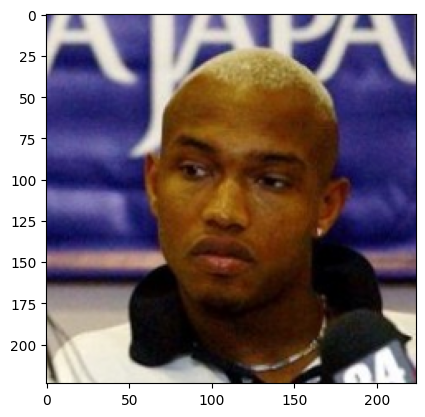

Hello, Human!
Let me guess.
Your name is hound, Pharaoh hound.


In [57]:
run_app("./lfw/El_Hadji_Diouf/El_Hadji_Diouf_0001.jpg")

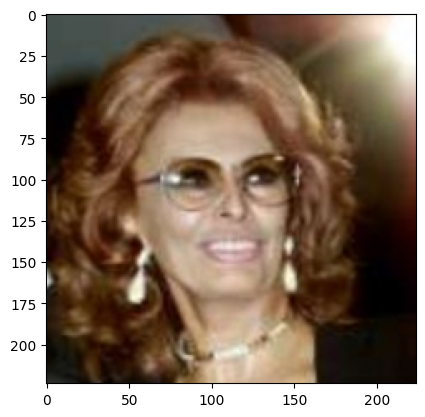

Hello, Human!
Let me guess.
Your name is spaniel, Boykin spaniel.


In [58]:
run_app("./lfw/Sophia_Loren/Sophia_Loren_0006.jpg")

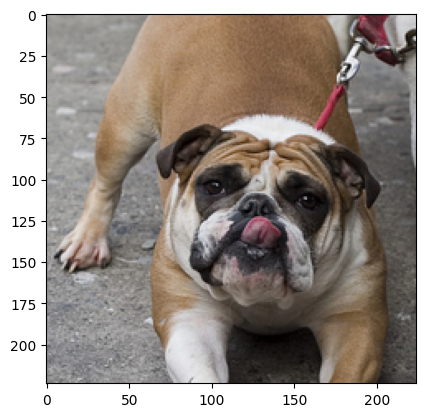

Who's a good boy, Bulldog...


In [59]:
run_app("./dog_images/test/040.Bulldog/Bulldog_02817.jpg")

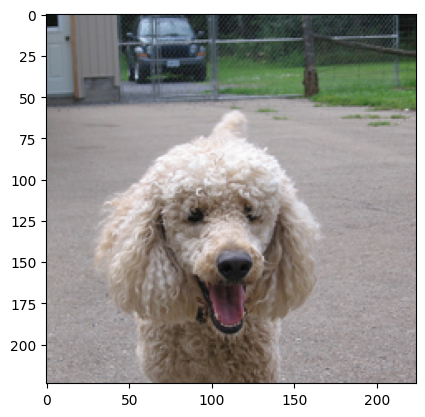

Who's a good boy, Poodle...


In [60]:
run_app("./dog_images/test/124.Poodle/Poodle_07925.jpg")

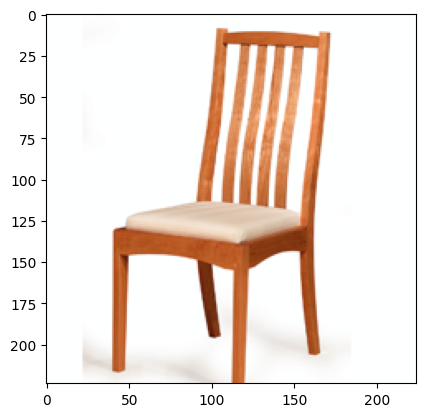

hmm...


In [61]:
run_app("./test_images/Screenshot.png")

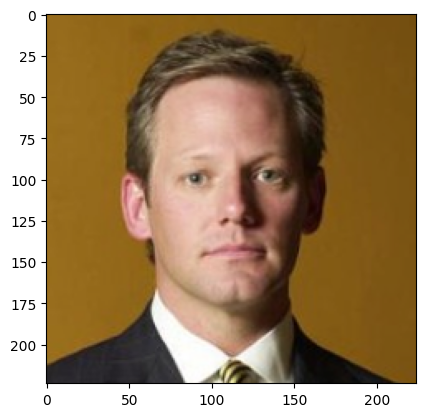

Hello, Human!
Let me guess.
Your name is Basenji.


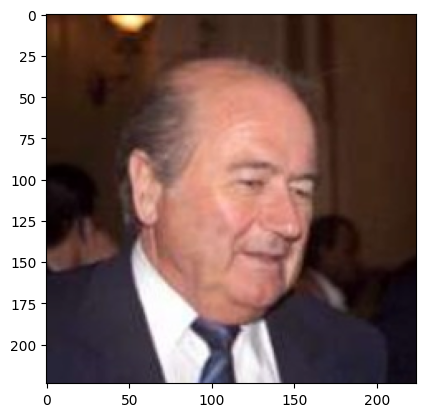

hmm...


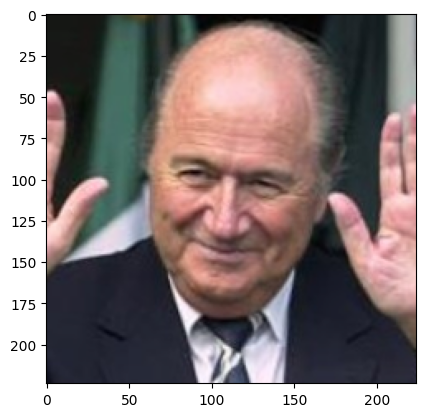

Hello, Human!
Let me guess.
Your name is Chihuahua.


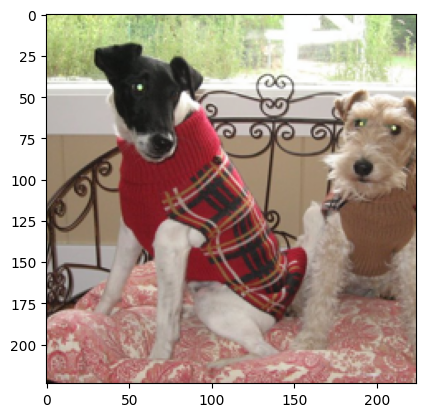

Who's a good boy, Italian greyhound...


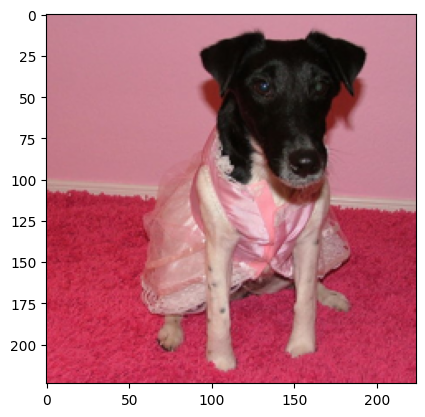

Who's a good boy, Smooth fox terrier...


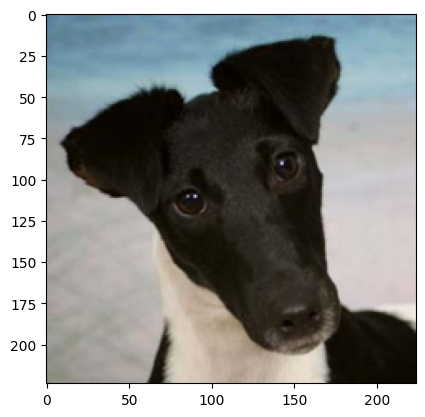

Who's a good boy, Smooth fox terrier...


In [62]:
## TODO: Execute your algorithm from Step 6 on
## at least 6 images on your computer.
## Feel free to use as many code cells as needed.

## suggested code, below
for file in np.hstack((human_files[:3], dog_files[:3])):
    run_app(file)